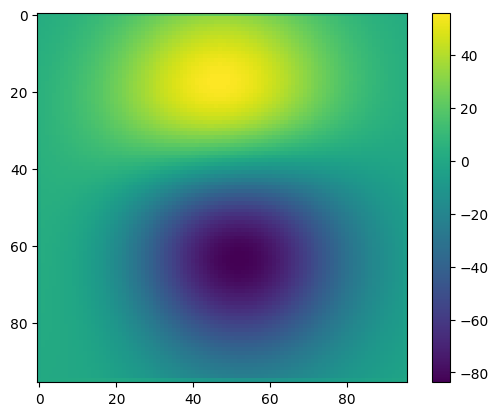

interactive(children=(FloatSlider(value=0.7, description='ESP (ms)', max=1.6, min=0.3, step=0.05), Output()), …

<function __main__.demo(esp_ms=0.7)>

In [ ]:
# %% [markdown]
# Interactive EPI simulation with blip-up/down and Nyquist ghost correction.
# Adjust **Echo Spacing (ESP)** with the slider to see distortion flip and scale.
#
# Layout (2 rows x 2 cols):
# [0,0] blip-up  (with ghost)
# [0,1] blip-down (with ghost)
# [1,0] blip-up  (ghost-corrected)
# [1,1] blip-down (ghost-corrected)

%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np 
from ipywidgets import interact, FloatSlider
from IPython.display import display
import os

# -------------------------
# Utilities
# -------------------------
def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k)))

def make_circular_phantom(N=96, radius=0.35, add_soft_gradient=True):
    """Unit circle; optional soft interior gradient so low-f ghosts are visible."""
    y, x = np.mgrid[-0.5:0.5:N*1j, -0.5:0.5:N*1j]
    r = np.sqrt(x**2 + y**2)
    ph = (r <= radius).astype(float)
    if add_soft_gradient:
        ph = ph * (0.65 + 0.35*(0.5 - r)/radius).clip(0, 1)
    return ph

def smooth_fieldmap(N=96, max_hz=180.0, seeds=4, falloff=0.22, rng=123):
    """Simple smooth Δf (Hz) map to create realistic PE distortion."""
    rs = np.random.RandomState(rng)
    y, x = np.mgrid[-0.5:0.5:N*1j, -0.5:0.5:N*1j]
    fmap = np.zeros((N, N), dtype=float)
    for _ in range(seeds):
        cx, cy = rs.uniform(-0.25, 0.25, size=2)
        amp = rs.uniform(-1.0, 1.0) * max_hz
        d2 = (x - cx)**2 + (y - cy)**2
        fmap += amp * np.exp(-d2 / (2*falloff**2))
    # light FFT low-pass for smoothness
    K = np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(fmap)))
    ky, kx = np.mgrid[-N//2:N//2, -N//2:N//2]
    lp = np.exp(-0.5*((kx/(0.25*N))**2 + (ky/(0.25*N))**2))
    fmap_s = np.real(np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(K * lp))))
    return fmap_s

# -------------------------
# EPI acquisition + reconstruction
# -------------------------
def epi_acquire_kspace(
    obj,
    fmap_hz,
    ESP_s=0.0007,
    phi0_deg=20.0,     # zero-order even/odd offset -> low-f ghost
    alpha=0.4,         # linear ramp across kx on even lines -> high-f ghost
    pe_dir="up"        # "up" or "down" (flips distortion direction)
):
    """
    Return:
      k_epi_sampled  : as acquired (zig-zag in kx)
      k_epi_dezigzag : after reversing odd lines (ready for IFFT)
      img_with_ghost : reconstructed image (with Nyquist ghost)
    """
    N = obj.shape[0]
    kx_norm = np.linspace(-1, 1, N, endpoint=False)
    phi0 = np.deg2rad(phi0_deg)
    even_phase = np.exp(1j * (phi0 + alpha * kx_norm))   # applied to EVEN ky lines only

    ky_center = N // 2
    k_epi_sampled = np.zeros((N, N), dtype=complex)

    # Single-shot EPI: one ky line per echo; time offsets produce PE distortion
    for iy in range(N):
        sign = +1 if pe_dir == "up" else -1
        t_line = sign * (iy - ky_center) * ESP_s     # time of line acquisition
        obj_t = obj * np.exp(1j * 2*np.pi * fmap_hz * t_line)  # off-resonance phase accrual
        k_full_t = fft2c(obj_t)

        line = k_full_t[iy, :].copy()
        if (iy % 2) == 0:            # even ky line -> apply even/odd phase error
            line *= even_phase
        if (iy % 2) == 1:            # zig-zag readout reversal
            line = line[::-1]
        k_epi_sampled[iy, :] = line

    # De-zigzag before IFFT (reverse odd lines back)
    k_epi_dezigzag = k_epi_sampled.copy()
    for iy in range(N):
        if (iy % 2) == 1:
            k_epi_dezigzag[iy, :] = k_epi_dezigzag[iy, ::-1]

    img_with_ghost = ifft2c(k_epi_dezigzag)
    return k_epi_sampled, k_epi_dezigzag, img_with_ghost

def apply_simple_ghost_correction(k_epi_dezigzag, phi0_deg=20.0, alpha=0.4):
    """
    Simple *a priori* Nyquist correction:
      multiply EVEN ky lines by the inverse of the known error exp(-i*(phi0 + alpha*kx)).
    This demonstrates the concept (like a perfect navigator). In practice you'd estimate these.
    """
    N = k_epi_dezigzag.shape[0]
    kx_norm = np.linspace(-1, 1, N, endpoint=False)
    inv_phase = np.exp(-1j * (np.deg2rad(phi0_deg) + alpha * kx_norm))

    k_corr = k_epi_dezigzag.copy()
    for iy in range(N):
        if (iy % 2) == 0:  # undo the even-line phase
            k_corr[iy, :] *= inv_phase
    img_corr = ifft2c(k_corr)
    return img_corr

# -------------------------
# Static scene setup
# -------------------------
N = 96
phantom = make_circular_phantom(N=N, radius=0.35, add_soft_gradient=True)
fmap = smooth_fieldmap(N=N, max_hz=180.0, seeds=4, falloff=0.22, rng=7)

# fmap = 60 * np.ones_like(fmap)
fmap = -fmap 

plt.figure()
plt.imshow(fmap)
plt.colorbar() 
plt.show()

# Fixed Nyquist parameters (you can change these constants if you want)
PHI0_DEG = 60.0
ALPHA     = 0.4

# -------------------------
# Interactive UI
# -------------------------
def demo(esp_ms=0.7):
    ESP_s = esp_ms / 1000.0

    # Acquire: BLIP-UP
    _, k_up, img_up = epi_acquire_kspace(
        phantom, fmap, ESP_s=ESP_s, phi0_deg=PHI0_DEG, alpha=ALPHA, pe_dir="up"
    )
    img_up_corr = apply_simple_ghost_correction(k_up, phi0_deg=PHI0_DEG, alpha=ALPHA)

    # Acquire: BLIP-DOWN (opposite distortion)
    _, k_dn, img_dn = epi_acquire_kspace(
        phantom, fmap, ESP_s=ESP_s, phi0_deg=PHI0_DEG, alpha=ALPHA, pe_dir="down"
    )
    img_dn_corr = apply_simple_ghost_correction(k_dn, phi0_deg=PHI0_DEG, alpha=ALPHA)

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for ax in axes.ravel():
        ax.axis('off')

    axes[0,0].imshow(np.abs(img_up), cmap='gray')
    axes[0,0].set_title(f"Blip-UP (ESP={esp_ms:.2f} ms) — with ghost")

    axes[0,1].imshow(np.abs(img_dn), cmap='gray')
    axes[0,1].set_title(f"Blip-DOWN (ESP={esp_ms:.2f} ms) — with ghost")

    axes[1,0].imshow(np.abs(img_up_corr), cmap='gray')
    axes[1,0].set_title("Blip-UP — ghost corrected")

    axes[1,1].imshow(np.abs(img_dn_corr), cmap='gray')
    axes[1,1].set_title("Blip-DOWN — ghost corrected")

    plt.tight_layout()
    plt.show()

# Slider over echo spacing (in milliseconds)
interact(
    demo,
    esp_ms=FloatSlider(value=0.7, min=0.3, max=1.6, step=0.05, description='ESP (ms)')
)

# Tip: If you want to also expose φ0 and α as sliders, you can wrap them as globals
# and rewrite demo() to read from them, or add more interact parameters.
